# Redes Sociais e Saúde Mental
## MVP — Análise Exploratória e Pré-processamento de Dados

**Aluno:** Esther Martins Nóbrega <br>
**Matricula:** 4052025002591 <br>
**Curso:** Pós-Graduação em Ciência de Dados e Analytics — PUC-Rio  
**Disciplina:** Análise Exploratória e Pré-processamento de Dados  
**Dataset:** [Social Media and Mental Health — Kaggle (souvikahmed071)](https://raw.githubusercontent.com/e-sthe-r/mvp-analise-dados-saude-mental/refs/heads/main/smmh.csv)

---

## 1. Contexto e Definição do Problema

O uso de redes sociais cresceu de forma acelerada na última década e se tornou parte central da rotina de bilhões de pessoas. Paralelamente, estudos em saúde mental apontam aumento nos índices de ansiedade, depressão e dificuldades de concentração, especialmente entre jovens adultos.

Este MVP busca identificar relações entre o tempo de uso de redes sociais e indicadores de saúde mental com a seguinte **pergunta central**:

> **O volume de uso diário de redes sociais está associado a maiores índices de sintomas relacionados à saúde mental — como ansiedade, distração, comparação social e depressão?**

### Tipo de problema
Este é um problema de **aprendizado não supervisionado** na etapa de análise exploratória: não há uma variável-alvo definida a priori. O objetivo é identificar padrões, correlações e distribuições nos dados que possam responder à pergunta central.


### Hipóteses do Problema

1. Usuários que passam mais horas por dia em redes sociais apresentam maiores índices de ansiedade e distração.
2. A frequência de comparação social nas redes está positivamente associada a sentimentos de depressão.
3. Usuários mais jovens tendem a apresentar maiores índices de impacto na saúde mental.
4. O uso sem propósito definido é um indicador de comportamento compulsivo e se correlaciona com baixa autoestima.

### Restrições e condições de seleção dos dados
- O dataset foi coletado via survey estruturado em ambiente universitário.
- A amostra **não é representativa** da população geral: os resultados devem ser interpretados no contexto do perfil amostrado.

---

## 2. Dicionário de Atributos

O dataset possui **21 colunas** e **481 registros**. A primeira coluna é o Timestamp do preenchimento, seguida de 20 questões numeradas. Abaixo, a descrição de cada atributo:

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| Timestamp | Categórica | Data/hora do preenchimento do survey |
| 1. What is your age? | Numérica | Idade do respondente |
| 2. Gender | Categórica | Gênero (Male, Female, Non-binary, etc.) |
| 3. Relationship Status | Categórica | Estado civil/relacionamento |
| 4. Occupation Status | Categórica | Situação ocupacional (estudante, empregado, etc.) |
| 5. What type of organizations are you affiliated with? | Categórica | Tipo de organização (universidade, empresa, etc.) |
| 6. Do you use social media? | Categórica | Usa redes sociais? (Sim/Não) |
| 7. What social media platforms do you commonly use? | Categórica | Plataformas utilizadas (lista múltipla) |
| 8. What is the average time you spend on social media every day? | Categórica ordinal | Faixa de horas diárias |
| 9. How often do you find yourself using Social media without a specific purpose? | Numérica (1-5) | Uso sem propósito definido |
| 10. How often do you get distracted by Social media when you are busy doing something? | Numérica (1-5) | Distração durante atividades |
| 11. Do you feel restless if you haven't used Social media in a while? | Numérica (1-5) | Inquietação por ausência das redes |
| 12. On a scale of 1 to 5, how easily distracted are you? | Numérica (1-5) | Facilidade geral de distração |
| 13. On a scale of 1 to 5, how much are you bothered by worries? | Numérica (1-5) | Nível de preocupação/ansiedade |
| 14. Do you find it difficult to concentrate on things? | Numérica (1-5) | Dificuldade de concentração |
| 15. How often do you compare yourself to other successful people through the use of social media? | Numérica (1-5) | Frequência de comparação social |
| 16. How do you feel about these comparisons, generally speaking? | Numérica (1-5) | Sentimento gerado pelas comparações |
| 17. How often do you look to seek validation from features of social media? | Numérica (1-5) | Busca por validação social |
| 18. How often do you feel depressed or down? | Numérica (1-5) | Frequência de sentimentos depressivos |
| 19. How frequently does your interest in daily activities fluctuate? | Numérica (1-5) | Flutuação de interesse em atividades |
| 20. How often do you face issues regarding sleep? | Numérica (1-5) | Problemas de sono |

---

## 3. Importação de Bibliotecas

Todas as dependências necessárias para análise, visualização e pré-processamento dos dados serão importadas a seguir.

In [29]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Configurações gerais de visualização
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

# Suprimir avisos desnecessários
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 4. Carregamento dos Dados

In [30]:
# URL raw do dataset no repositório público do GitHub
URL_DATASET = 'https://raw.githubusercontent.com/e-sthe-r/mvp-analise-dados-saude-mental/refs/heads/main/smmh.csv'

# Carregamento do dataset
df = pd.read_csv(URL_DATASET)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')

Dataset carregado com sucesso!
Dimensões: 481 linhas × 21 colunas


---
## 5. Análise Exploratória dos Dados (EDA)

Esta seção tem como objetivo entender a estrutura, distribuição e qualidade dos dados antes de qualquer transformação.

### 5.1 Primeiros registros e estrutura geral

In [31]:
# Visualizar as primeiras linhas do dataset
df.head()

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


In [32]:
# Informações gerais: tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    object 
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    object 
 3   3. Relationship Status                                                                                                481 non-null    object 
 4   4. Occup

## Análise da Estrutura do Dataset

Ao analisar a estrutura do dataset por meio do método `df.info()`, foi observado que a base de dados é composta por **481 registros e 21 atributos**, apresentando boa integridade geral.

Não foram identificados valores ausentes na maioria das variáveis, com exceção da coluna *“What type of organizations are you affiliated with?”*, que apresenta algumas entradas nulas.

---

### Tipos de Dados

Em relação aos tipos de dados, nota-se que a maior parte das variáveis relacionadas a escalas (1 a 5) está corretamente representada como valores numéricos inteiros (`int64`), o que facilita análises estatísticas e cálculos posteriores.

A variável **idade** encontra-se como `float64`, sendo importante avaliar a necessidade de conversão para inteiro, caso não haja casas decimais relevantes.

---

### Variáveis Categóricas

Algumas colunas estão representadas como `object`, incluindo variáveis como:

* Gênero
* Status de relacionamento
* Ocupação

Essas variáveis poderão ser transformadas posteriormente para formatos adequados, como codificação categórica, a fim de viabilizar análises mais estruturadas.

---

### Variável de Tempo de Uso

A variável referente ao *tempo médio diário de uso de redes sociais* encontra-se em formato textual, caracterizando uma variável **ordinal categórica**.

Será necessário convertê-la para uma representação numérica ou ordinal na etapa de pré-processamento, permitindo análises quantitativas mais precisas.

---

### Variável Multivalorada

A variável que descreve as *plataformas de redes sociais utilizadas* apresenta múltiplos valores em uma única célula, separados por delimitadores (vírgulas).

Essa característica indica um atributo **multivalorado**, que demandará tratamento específico, como a separação em múltiplas colunas (one-hot encoding), para possibilitar análises mais detalhadas.

---

### Considerações Gerais

De modo geral, o dataset apresenta **boa qualidade estrutural**, sendo necessário principalmente realizar transformações e engenharia de atributos para adequação às análises propostas.




### 5.2 Renomeação das colunas

Os nomes originais são perguntas longas. Renomearemos para facilitar a manipulação, seguindo boas práticas de nomenclatura.

In [33]:
# Dicionário de renomeação: nomes curtos e descritivos
novos_nomes = {
    df.columns[0]:  'timestamp',
    df.columns[1]:  'idade',
    df.columns[2]:  'genero',
    df.columns[3]:  'status_relacionamento',
    df.columns[4]:  'ocupacao',
    df.columns[5]:  'tipo_organizacao',
    df.columns[6]:  'usa_redes_sociais',
    df.columns[7]:  'plataformas',
    df.columns[8]:  'tempo_diario',
    df.columns[9]:  'uso_sem_proposito',
    df.columns[10]: 'distracao_por_redes',
    df.columns[11]: 'inquietacao_sem_redes',
    df.columns[12]: 'facilidade_distracao',
    df.columns[13]: 'nivel_preocupacao',
    df.columns[14]: 'dificuldade_concentracao',
    df.columns[15]: 'comparacao_social',
    df.columns[16]: 'sentimento_comparacao',
    df.columns[17]: 'busca_validacao',
    df.columns[18]: 'sentimento_depressao',
    df.columns[19]: 'flutuacao_interesse',
    df.columns[20]: 'problemas_sono'
}

df = df.rename(columns=novos_nomes)

print('Colunas renomeadas:')
print(df.columns.tolist())

Colunas renomeadas:
['timestamp', 'idade', 'genero', 'status_relacionamento', 'ocupacao', 'tipo_organizacao', 'usa_redes_sociais', 'plataformas', 'tempo_diario', 'uso_sem_proposito', 'distracao_por_redes', 'inquietacao_sem_redes', 'facilidade_distracao', 'nivel_preocupacao', 'dificuldade_concentracao', 'comparacao_social', 'sentimento_comparacao', 'busca_validacao', 'sentimento_depressao', 'flutuacao_interesse', 'problemas_sono']


### 5.3 Estatísticas descritivas

In [34]:
# Resumo estatístico das variáveis numéricas
df.describe().round(2)

,idade,uso_sem_proposito,distracao_por_redes,inquietacao_sem_redes,facilidade_distracao,nivel_preocupacao,dificuldade_concentracao,comparacao_social,sentimento_comparacao,busca_validacao,sentimento_depressao,flutuacao_interesse,problemas_sono
count,481.00,481.00,481.00,481.00,481.00,481.00,481.00,481.00,481.00,481.00,481.00,481.00,481.00
mean,26.14,3.55,3.32,2.59,3.35,3.56,3.25,2.83,2.78,2.46,3.26,3.17,3.20
std,9.92,1.10,1.33,1.26,1.18,1.28,1.35,1.41,1.06,1.25,1.31,1.26,1.46
min,13.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,21.00,3.00,2.00,2.00,3.00,3.00,2.00,2.00,2.00,1.00,2.00,2.00,2.00
50%,22.00,4.00,3.00,2.00,3.00,4.00,3.00,3.00,3.00,2.00,3.00,3.00,3.00
75%,26.00,4.00,4.00,3.00,4.00,5.00,4.00,4.00,3.00,3.00,4.00,4.00,5.00
max,91.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


## Análise Estatística Descritiva

A análise do resumo estatístico (`df.describe()`) permite compreender a distribuição das variáveis numéricas presentes no dataset.

Observa-se que todas as variáveis de escala (1 a 5) apresentam valores mínimos e máximos dentro do intervalo esperado, não sendo identificados valores inconsistentes ou fora do domínio das respostas. Esse comportamento indica boa qualidade e padronização dos dados coletados.

---

### Distribuição das Variáveis

As médias das variáveis relacionadas a comportamento e saúde mental concentram-se majoritariamente entre **2,5 e 3,5**, sugerindo uma tendência moderada nas respostas dos participantes.

Por exemplo:

* **uso_sem_proposito (média ≈ 3,55)** indica que os participantes frequentemente utilizam redes sociais sem um objetivo específico
* **nivel_preocupacao (média ≈ 3,56)** sugere níveis moderados de preocupação entre os indivíduos
* **sentimento_depressao (média ≈ 3,26)** aponta presença relevante de sentimentos negativos em parte da amostra

---

### Perfil da Amostra

A variável **idade** apresenta:

* Média: aproximadamente 26 anos
* Mediana: 22 anos

Essa diferença entre média e mediana sugere uma **assimetria à direita**, indicando a presença de alguns indivíduos com idade mais elevada, embora a maioria da amostra seja composta por jovens adultos.

---

### Variabilidade dos Dados

O desvio padrão das variáveis situa-se, em geral, entre **1,0 e 1,4**, indicando uma dispersão moderada nas respostas.

Isso sugere que:

* Há variação significativa entre os indivíduos
* As respostas não estão excessivamente concentradas em um único valor

---

### Considerações Gerais

De forma geral, os dados apresentam:

* Boa distribuição
* Ausência de valores inconsistentes
* Variabilidade adequada para análise

Essas características tornam o dataset apropriado para a realização de análises exploratórias mais aprofundadas, incluindo investigações de correlação entre uso de redes sociais e indicadores de saúde mental.


### 5.4 Análise de valores faltantes

In [35]:
# Contagem e percentual de valores nulos por coluna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    '% do total': pct_nulos
})

# Exibir apenas colunas com pelo menos 1 nulo
resumo_nulos = resumo_nulos[resumo_nulos['Valores nulos'] > 0]

if resumo_nulos.empty:
    print('Nenhum valor nulo encontrado no dataset.')
else:
    display(resumo_nulos)

,Valores nulos,% do total
tipo_organizacao,30,6.24


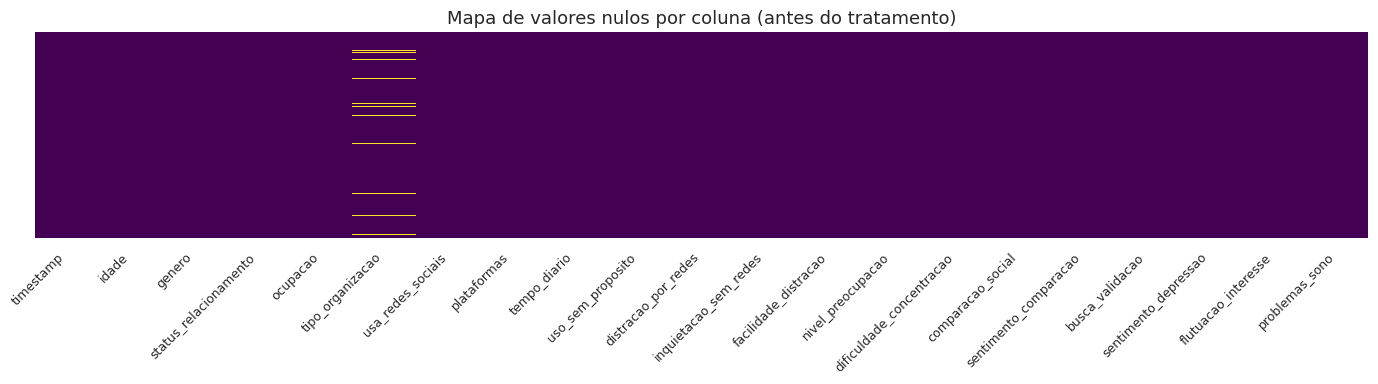

In [36]:
# Heatmap visual de valores nulos
plt.figure(figsize=(14, 4))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False
)
plt.title('Mapa de valores nulos por coluna (antes do tratamento)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


## Análise de Valores Ausentes

A análise de valores ausentes identificou a presença de dados nulos apenas na variável **tipo_organizacao**, com um total de 30 ocorrências, representando aproximadamente **6,24% do dataset**.

As demais variáveis não apresentaram valores ausentes, indicando boa completude dos dados.

---

### Avaliação dos Dados Ausentes

O heatmap de valores nulos permite visualizar a completude do dataset de forma intuitiva, evidenciando a presença ou ausência de dados em cada variável.

Considerando que a variável afetada é categórica e que a proporção de valores nulos não é elevada, optou-se por **não remover os registros**, a fim de evitar perda desnecessária de informações.

---

### Tratamento Adotado

Os valores ausentes foram substituídos por uma nova categoria denominada **“Não informado”**, permitindo preservar os dados e manter a consistência da variável.

Essa abordagem é adequada para variáveis categóricas, pois evita a introdução de vieses decorrentes da exclusão de registros e mantém a integridade da base para análises futuras.


In [37]:
# Substituindo valores nulos por categoria "Não informado"
df['tipo_organizacao'] = df['tipo_organizacao'].fillna('Não informado')

### 5.5 Distribuição das variáveis categóricas

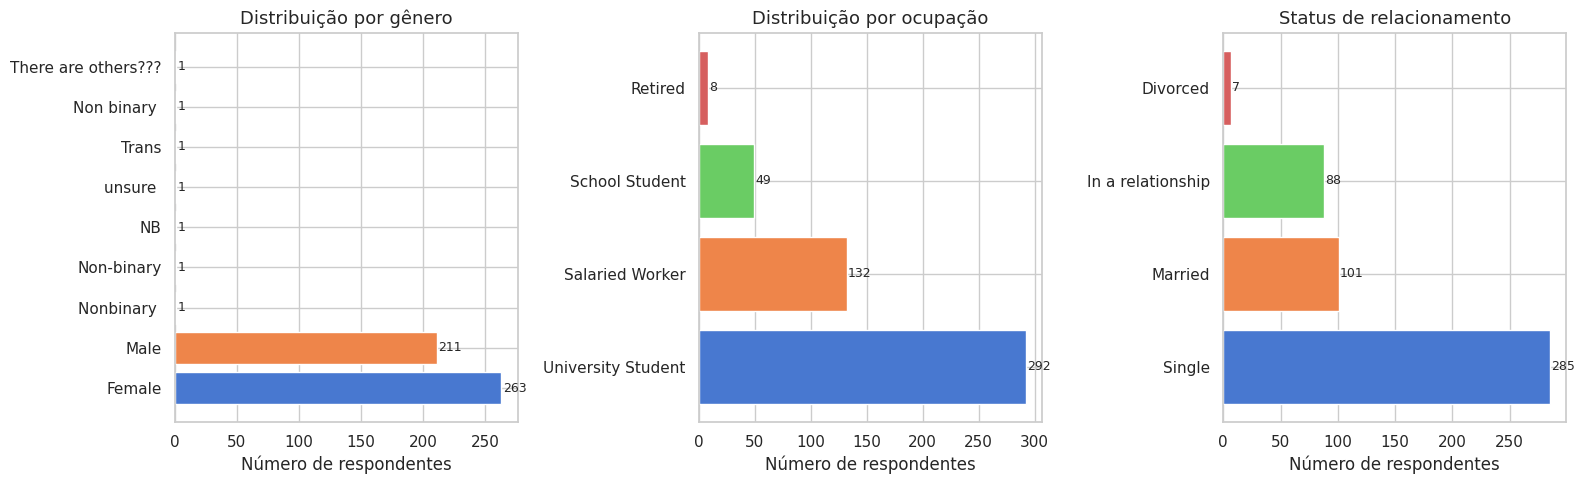

In [38]:
# Distribuição por gênero
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colunas_categoricas = ['genero', 'ocupacao', 'status_relacionamento']
titulos = ['Distribuição por gênero', 'Distribuição por ocupação', 'Status de relacionamento']

for ax, coluna, titulo in zip(axes, colunas_categoricas, titulos):
    contagem = df[coluna].value_counts()
    ax.barh(contagem.index, contagem.values, color=sns.color_palette('muted', len(contagem)))
    ax.set_title(titulo)
    ax.set_xlabel('Número de respondentes')
    # Adicionar rótulos de valor em cada barra
    for i, v in enumerate(contagem.values):
        ax.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Distribuição das Variáveis Categóricas

A análise das variáveis categóricas permite compreender o perfil dos participantes da pesquisa, oferecendo contexto importante para a interpretação dos resultados relacionados à saúde mental.

---

### Gênero

É possível observar uma predominância de respondentes do gênero **feminino (263)** em relação ao masculino (211), enquanto as demais categorias apresentam representatividade bastante reduzida.

Essa distribuição indica um leve desequilíbrio na amostra, o que deve ser considerado na interpretação dos resultados, especialmente em análises comparativas entre grupos.

---

### Ocupação

A maioria dos participantes é composta por **estudantes universitários (292)**, seguida por trabalhadores assalariados (132). Outras categorias, como estudantes escolares e aposentados, possuem menor representatividade.

Esse perfil sugere que a amostra é majoritariamente jovem e inserida no ambiente acadêmico, o que pode influenciar diretamente padrões de uso de redes sociais e percepções relacionadas à saúde mental.

---

### Status de Relacionamento

Em relação ao status de relacionamento, observa-se predominância de indivíduos **solteiros (285)**, seguidos por casados (101) e em relacionamento (88).

Essa distribuição reforça o perfil jovem da amostra e pode estar associada a comportamentos específicos no uso de redes sociais, como maior exposição e interação digital.

---

### Considerações Gerais

De forma geral, a amostra apresenta um perfil predominantemente jovem, universitário e solteiro.

Essas características devem ser consideradas ao longo das análises, uma vez que podem influenciar tanto o comportamento nas redes sociais quanto os indicadores de saúde mental observados.


### 5.6 Distribuição do tempo diário em redes sociais

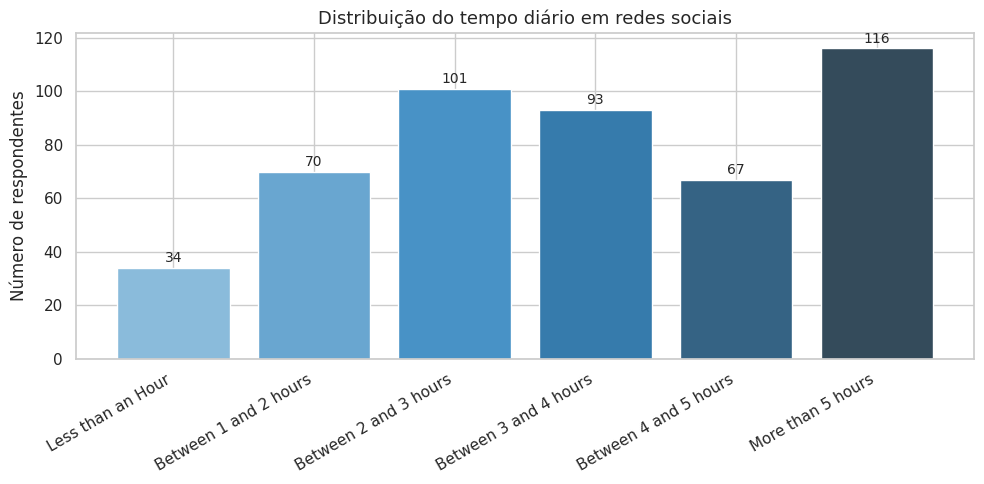

In [39]:
# Definir ordem lógica das categorias de tempo
ordem_tempo = [
    'Less than an Hour',
    'Between 1 and 2 hours',
    'Between 2 and 3 hours',
    'Between 3 and 4 hours',
    'Between 4 and 5 hours',
    'More than 5 hours'
]

contagem_tempo = df['tempo_diario'].value_counts().reindex(ordem_tempo, fill_value=0)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    range(len(contagem_tempo)),
    contagem_tempo.values,
    color=sns.color_palette('Blues_d', len(contagem_tempo))
)
plt.xticks(range(len(contagem_tempo)), contagem_tempo.index, rotation=30, ha='right')
plt.title('Distribuição do tempo diário em redes sociais')
plt.ylabel('Número de respondentes')

# Rótulos de valor
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

## Distribuição do Tempo Diário em Redes Sociais

A análise da variável **tempo_diario** permite compreender o padrão de uso de redes sociais entre os participantes.

Foi possível perceber que a maior concentração de respondentes está nas faixas de **2 a 3 horas (101)**, **3 a 4 horas (93)** e **mais de 5 horas (116)** diárias.

---

###  Padrões de Uso

Nota-se que uma parcela significativa dos indivíduos passa **mais de 2 horas por dia** em redes sociais, indicando um nível elevado de exposição digital.

Destacando também a categoria **“More than 5 hours”**, que apresenta o maior número de respondentes, sugerindo a presença de um grupo com uso intensivo.

---

### Baixo Uso

Por outro lado, a menor concentração está na faixa de **menos de 1 hora (34)**, indicando que poucos participantes possuem uso reduzido de redes sociais.

---

### Considerações

De forma geral, os dados indicam um padrão de uso relativamente alto entre os participantes, o que pode estar associado a possíveis impactos nos indicadores de saúde mental.


### 5.7 Distribuição das variáveis de escala (1 a 5)

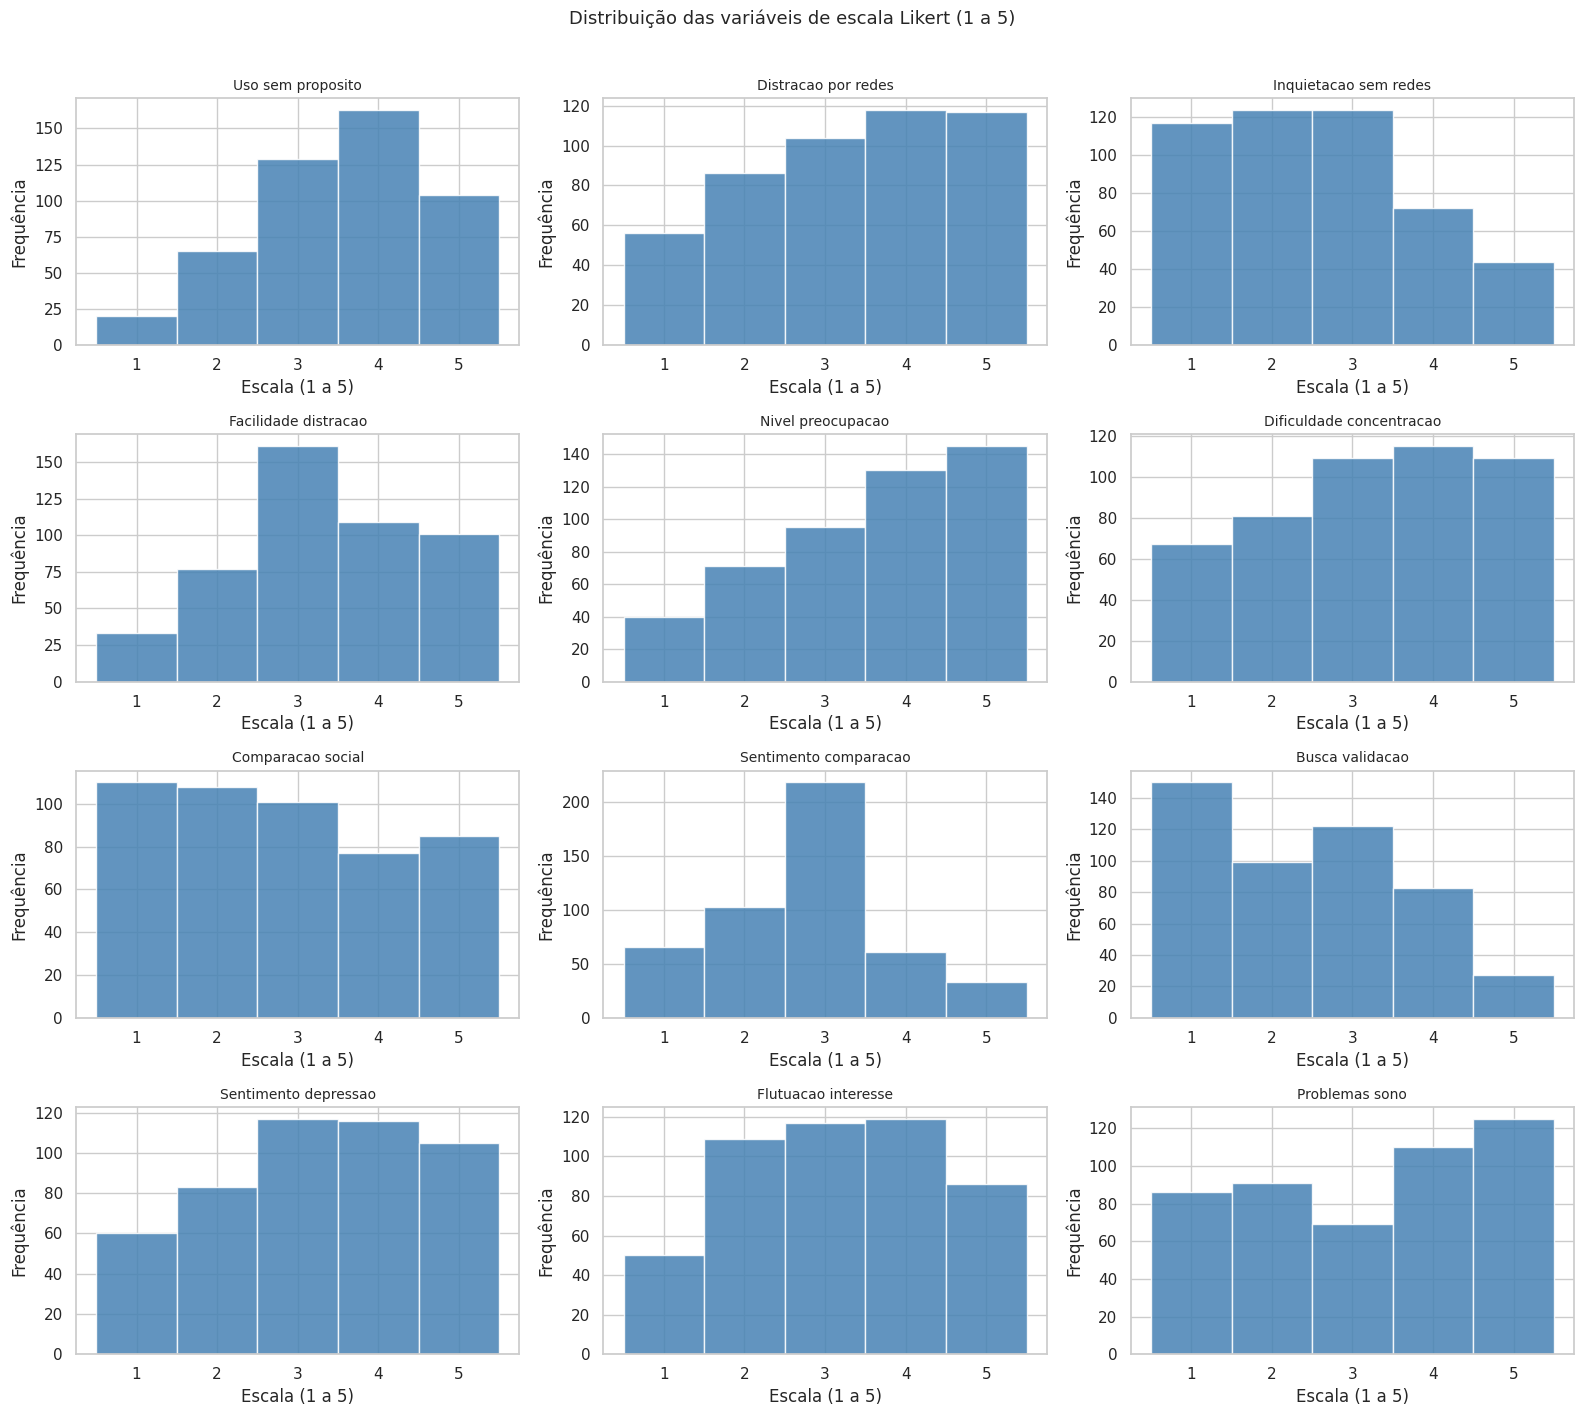

In [40]:
# Colunas numéricas de escala Likert (1 a 5)
colunas_escala = [
    'uso_sem_proposito', 'distracao_por_redes', 'inquietacao_sem_redes',
    'facilidade_distracao', 'nivel_preocupacao', 'dificuldade_concentracao',
    'comparacao_social', 'sentimento_comparacao', 'busca_validacao',
    'sentimento_depressao', 'flutuacao_interesse', 'problemas_sono'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, coluna in enumerate(colunas_escala):
    axes[i].hist(
        df[coluna].dropna(),
        bins=5, range=(0.5, 5.5),
        color='steelblue', edgecolor='white', alpha=0.85
    )
    axes[i].set_title(coluna.replace('_', ' ').capitalize(), fontsize=10)
    axes[i].set_xlabel('Escala (1 a 5)')
    axes[i].set_ylabel('Frequência')
    axes[i].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Distribuição das variáveis de escala Likert (1 a 5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Distribuição das Variáveis de Escala Likert (1 a 5)

### Tendências Gerais

A maioria das variáveis apresenta concentração nas faixas intermediárias e superiores da escala (valores 3, 4 e 5), indicando que os participantes tendem a relatar níveis moderados a elevados nos aspectos analisados.

---

### Uso de Redes Sociais e Distração

Variáveis como **uso_sem_proposito**, **distracao_por_redes** e **facilidade_distracao** apresentam maior frequência em valores elevados (4 e 5), sugerindo que o uso frequente e a distração causada pelas redes sociais são comportamentos comuns entre os respondentes.

---

### Indicadores Emocionais

As variáveis **nivel_preocupacao**, **sentimento_depressao** e **problemas_sono** também apresentam distribuição inclinada para valores mais altos, indicando presença relevante de sintomas associados a estresse, ansiedade e dificuldades relacionadas ao sono.

---

### Atenção e Concentração

A variável **dificuldade_concentracao** apresenta distribuição relativamente equilibrada, porém com leve tendência a valores mais altos, sugerindo que uma parcela significativa dos participantes enfrenta dificuldades de foco.

---

### Comparação Social e Validação

As variáveis **comparacao_social** e **busca_validacao** apresentam maior dispersão, com respostas distribuídas ao longo de toda a escala, indicando diferentes níveis de impacto das redes sociais na percepção social dos indivíduos.

---

### Considerações Gerais

De forma geral, os resultados indicam que os participantes apresentam níveis moderados a elevados em diversos indicadores relacionados ao uso de redes sociais e saúde mental.

Esses padrões reforçam a relevância da investigação proposta e indicam possíveis associações entre uso intensivo de redes sociais e impactos negativos no bem-estar psicológico, que serão exploradas em análises subsequentes.


### 5.8 Matriz de correlação

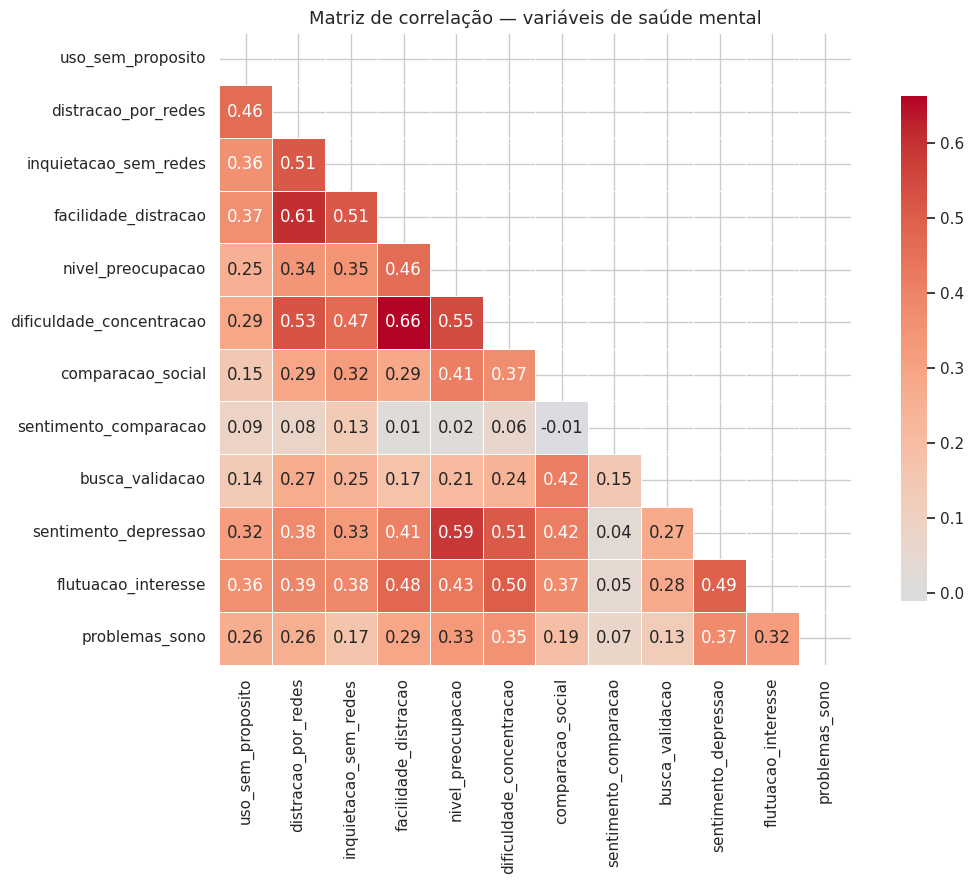

In [41]:
# Selecionar apenas colunas numéricas para correlação
df_numerico = df[colunas_escala]

# Calcular matriz de correlação de Pearson
matriz_corr = df_numerico.corr()

# Heatmap
plt.figure(figsize=(12, 9))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))  # Máscara triangular superior

sns.heatmap(
    matriz_corr,
    mask=mascara,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de correlação — variáveis de saúde mental')
plt.tight_layout()
plt.show()

## Análise de Correlação entre Variáveis de Saúde Mental

A matriz de correlação permite identificar relações lineares entre as variáveis analisadas, mostrando como diferentes aspectos do comportamento e da saúde mental estão associados.

---

### Correlações Mais Fortes

Algumas correlações moderadas a fortes entre variáveis relacionadas à distração e dificuldades cognitivas:

* **facilidade_distracao × dificuldade_concentracao (r ≈ 0,66)**
* **distracao_por_redes × facilidade_distracao (r ≈ 0,61)**
* **nivel_preocupacao × sentimento_depressao (r ≈ 0,59)**

Esses resultados sugerem que indivíduos mais suscetíveis à distração tendem a apresentar maior dificuldade de concentração, além de possíveis associações com indicadores emocionais negativos.

---

### Uso de Redes Sociais e Impactos Cognitivos

Variáveis relacionadas ao uso de redes sociais, como:

* **uso_sem_proposito**
* **distracao_por_redes**

apresentam correlações positivas com variáveis como dificuldade de concentração e flutuação de interesse, indicando que o uso frequente pode estar associado a impactos na atenção e foco.

---

### Indicadores Emocionais

Observa-se que variáveis como:

* **nivel_preocupacao**
* **sentimento_depressao**
* **problemas_sono**

apresentam correlações positivas entre si, sugerindo que esses fatores podem estar inter-relacionados e refletir um mesmo conjunto de sintomas relacionados ao bem-estar psicológico.

---

### Correlações Fracas ou Nulas

Algumas variáveis, como **sentimento_comparacao**, apresentam correlações muito baixas com as demais, indicando que esse fator pode atuar de forma mais independente dentro do contexto analisado.

---

### Considerações Gerais

De forma geral, foi possível observar um conjunto consistente de correlações positivas entre variáveis relacionadas ao uso de redes sociais, distração, dificuldades cognitivas e indicadores emocionais.

Reforçando a hipótese de que o uso intensivo de redes sociais pode estar associado a impactos negativos na saúde mental, embora não seja possível inferir causalidade a partir dessa análise.


### 5.9 Boxplot: tempo diário × indicadores de saúde mental

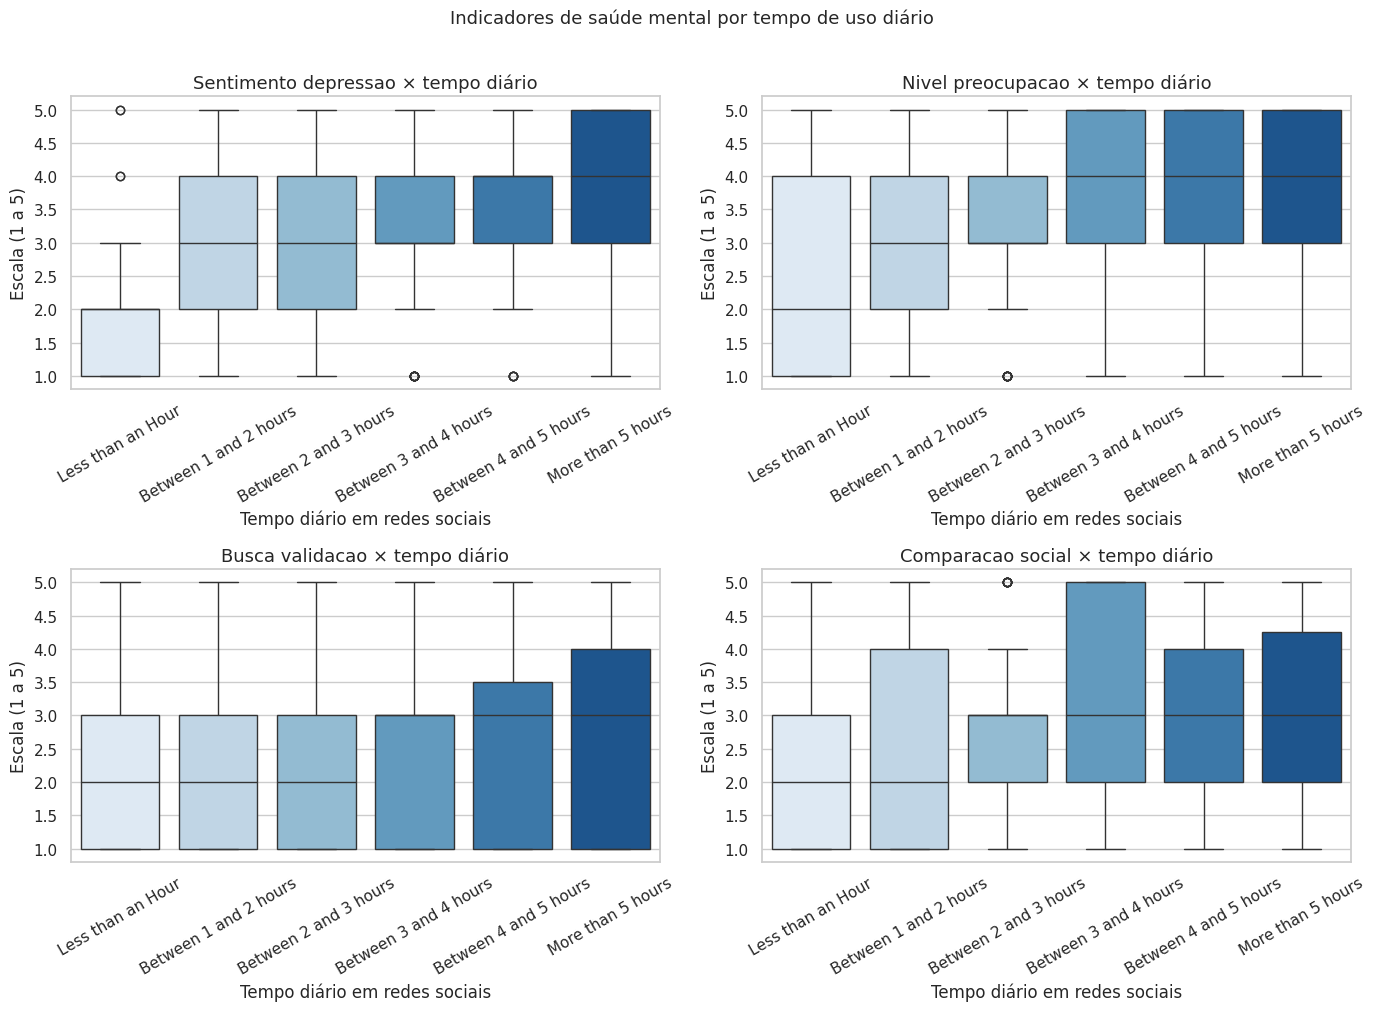

In [42]:
# Variáveis de interesse para cruzar com tempo diário
variaveis_saude = [
    'sentimento_depressao',
    'nivel_preocupacao',
    'busca_validacao',
    'comparacao_social'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, variavel in enumerate(variaveis_saude):
    # Filtrar apenas quem usa redes sociais
    df_filtrado = df[df['usa_redes_sociais'] == 'Yes']

    sns.boxplot(
        data=df_filtrado,
        x='tempo_diario',
        y=variavel,
        order=ordem_tempo,
        palette='Blues',
        ax=axes[i]
    )
    axes[i].set_title(f'{variavel.replace("_", " ").capitalize()} × tempo diário')
    axes[i].set_xlabel('Tempo diário em redes sociais')
    axes[i].set_ylabel('Escala (1 a 5)')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Indicadores de saúde mental por tempo de uso diário', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Relação entre Tempo de Uso e Indicadores de Saúde Mental

Por meio desse boxplots é possível observar como os indicadores de saúde mental variam de acordo com o tempo diário de uso de redes sociais.

---

### Sentimento de Depressão

Há uma tendência de aumento nos valores de `sentimento_depressao` conforme cresce o tempo de uso diário.

Usuários que passam mais de 4 ou 5 horas em redes sociais apresentam medianas mais elevadas e maior dispersão, indicando maior incidência de sentimentos depressivos nesse grupo.

---

### Nível de Preocupação

O `nivel_preocupacao` também apresenta crescimento gradual à medida que aumenta o tempo de uso.

As categorias com maior tempo diário concentram valores mais altos da escala, o que pode sugerir associação entre uso intensivo e níveis mais elevados de preocupação.

---

### Busca por Validação

A variável `busca_validacao` apresenta leve aumento nas categorias de maior uso, indicando que usuários mais ativos tendem a buscar mais reconhecimento ou validação nas redes sociais.

No entanto, essa relação parece menos intensa quando comparada a outras variáveis analisadas.

---

### Comparação Social

A variável `comparacao_social` apresenta maior dispersão, mas ainda assim é possível observar uma leve tendência de aumento nos níveis mais altos de uso.

Isso sugere que o tempo de exposição pode influenciar comportamentos de comparação com outros usuários, embora de forma menos consistente.

---

### Considerações Gerais

De forma geral, os resultados indicam que maiores níveis de uso de redes sociais estão associados a aumentos em diversos indicadores negativos de saúde mental.



## 6. Pré-processamento dos Dados

Com base nos achados da EDA, esta seção realiza as transformações necessárias para preparar os dados para análises futuras (incluindo modelos de machine learning).

### 6.1 Remoção de colunas irrelevantes

A coluna `timestamp` não agrega valor analítico (não há dimensão temporal relevante no survey) e será removida.

In [43]:
# Remover coluna de timestamp
df_proc = df.drop(columns=['timestamp'])

print(f'Coluna "timestamp" removida.')
print(f'   Dimensões atuais: {df_proc.shape}')

Coluna "timestamp" removida.
   Dimensões atuais: (481, 20)


### 6.2 Tratamento de valores faltantes

Após a etapa de análise exploratória, foi realizada a verificação de valores ausentes no dataset processado.

Anteriormente observou-se que os valores nulos estavam concentrados exclusivamente na variável `tipo_organizacao`, tendo sido previamente tratados por meio da substituição por uma categoria específica (“Não informado”).

In [44]:
# Verificar nulos restantes
nulos_restantes = df_proc.isnull().sum()

print('Valores nulos por coluna:')
print(nulos_restantes[nulos_restantes > 0])

# Validação final
if df_proc.isnull().sum().sum() == 0:
    print('\nNenhum valor nulo restante no dataset.')

print('\nTratamento de nulos concluído.')

Valores nulos por coluna:
Series([], dtype: int64)

Nenhum valor nulo restante no dataset.

Tratamento de nulos concluído.



### Verificação Final

Foi realizada uma nova verificação para garantir a ausência de valores nulos remanescentes no dataset:

---

### Estratégia Adotada

Considerando que os valores ausentes já haviam sido tratados anteriormente, não foi necessário aplicar métodos adicionais de imputação, como preenchimento por média, mediana ou moda.

Essa abordagem garante consistência no tratamento dos dados e evita alterações desnecessárias na distribuição original das variáveis.

---

### Considerações

A ausência de valores nulos no dataset final indica que a base encontra-se pronta para as etapas seguintes de transformação e modelagem, sem risco de inconsistências relacionadas a dados faltantes.


### 6.3 Tratamento da variável plataformas

A variável `plataformas` apresenta múltiplos valores em uma única célula, separados por vírgulas, caracterizando um atributo multivalorado.

Para permitir análises mais detalhadas, será aplicada uma transformação utilizando **one-hot encoding**, na qual cada plataforma passou a ser representada por uma coluna binária, indicando sua presença ou ausência para cada respondente, possibilitando analisar individualmente o uso de cada rede social.


In [45]:
# Limpar inconsistências nos dados (espaços extras)
df_proc['plataformas'] = df_proc['plataformas'].str.replace(', ', ',')
df_proc['plataformas'] = df_proc['plataformas'].str.strip()

# One-hot encoding para variável multivalorada
plataformas_dummies = df_proc['plataformas'].str.get_dummies(sep=',')

# Garantir nomes das colunas limpos
plataformas_dummies.columns = plataformas_dummies.columns.str.strip()

# Concatenar ao dataframe processado
df_proc = pd.concat([df_proc, plataformas_dummies], axis=1)

# Remover coluna original
df_proc = df_proc.drop(columns=['plataformas'])

# Visualizar resultado
df_proc.head()

,idade,genero,status_relacionamento,ocupacao,tipo_organizacao,usa_redes_sociais,tempo_diario,uso_sem_proposito,distracao_por_redes,inquietacao_sem_redes,...,problemas_sono,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube
0,21.0,Male,In a relationship,University Student,University,Yes,Between 2 and 3 hours,5,3,2,...,5,1,1,1,0,1,0,0,1,1
1,21.0,Female,Single,University Student,University,Yes,More than 5 hours,4,3,2,...,5,1,1,1,0,1,0,0,1,1
2,21.0,Female,Single,University Student,University,Yes,Between 3 and 4 hours,3,2,1,...,5,0,1,1,1,0,0,0,0,1
3,21.0,Female,Single,University Student,University,Yes,More than 5 hours,4,2,1,...,2,0,1,1,0,0,0,0,0,0
4,21.0,Female,Single,University Student,University,Yes,Between 2 and 3 hours,3,5,4,...,1,0,1,1,0,0,0,0,0,1


In [46]:
df_proc.columns[df_proc.columns.duplicated()]

Index([], dtype='object')

### Transformação Aplicada

Para permitir análises mais detalhadas, foi aplicada a técnica de **one-hot encoding**, na qual cada plataforma passou a ser representada por uma coluna binária (0 ou 1), indicando sua presença ou ausência para cada respondente.

Isso possibilita analisar individualmente o uso de cada rede social, permitindo investigar relações específicas entre plataformas e indicadores de saúde mental.

---

### Ajustes na Transformação

Durante a aplicação inicial do one-hot encoding, foi identificada a criação de colunas duplicadas.

A análise indicou que esse comportamento estava relacionado a inconsistências nos dados originais, como a presença de espaços em branco adicionais nos valores categóricos (por exemplo, diferenças entre “ Instagram” e “ Instagram”).

Para corrigir esse problema, foi realizada uma etapa prévia de limpeza e padronização dos dados, garantindo a remoção de espaços extras antes da transformação.

Essa etapa foi essencial para assegurar a consistência dos dados e evitar a criação de variáveis redundantes.

---

### Limpeza Estrutural

Após a criação das variáveis binárias, a coluna original **plataformas** foi removida, evitando redundância e tornando o dataset mais adequado para análises posteriores.

---

### Considerações

Essa transformação amplia a capacidade analítica do conjunto de dados, permitindo investigações mais precisas sobre o comportamento dos usuários em diferentes redes sociais.


### 6.4 Conversão da variável `tempo_diario` para numérico

A variável `tempo_diario` é originalmente categórica ordinal, representando faixas de tempo de uso de redes sociais.

Para permitir análises quantitativas, foi realizada a conversão dessa variável para formato numérico, utilizando o ponto médio de cada intervalo como valor representativo.

In [47]:
# Mapeamento: categoria de texto → valor numérico (ponto médio da faixa)
mapa_tempo = {
    'Less than an Hour':       0.5,
    'Between 1 and 2 hours':   1.5,
    'Between 2 and 3 hours':   2.5,
    'Between 3 and 4 hours':   3.5,
    'Between 4 and 5 hours':   4.5,
    'More than 5 hours':       6.0  # Estimativa para faixa aberta
}

# Criar nova coluna numérica
df_proc['tempo_diario_horas'] = df_proc['tempo_diario'].map(mapa_tempo)

print('Coluna "tempo_diario_horas" criada.')

# Verificar mapeamento (validação visual)
print('\nMapeamento aplicado:')
print(
    df_proc[['tempo_diario', 'tempo_diario_horas']]
    .drop_duplicates()
    .sort_values('tempo_diario_horas')
)

# Verificar se houve falha no mapeamento (valores nulos)
nulos_tempo = df_proc['tempo_diario_horas'].isnull().sum()
print(f'\nValores nulos após conversão: {nulos_tempo}')

if nulos_tempo == 0:
    print('Todos os valores foram convertidos corretamente.')

# Remover coluna original
df_proc = df_proc.drop(columns=['tempo_diario'])

print('\nColuna "tempo_diario" removida.')

# Visualizar resultado final
df_proc.head()

Coluna "tempo_diario_horas" criada.

Mapeamento aplicado:
             tempo_diario  tempo_diario_horas
9       Less than an Hour                 0.5
15  Between 1 and 2 hours                 1.5
0   Between 2 and 3 hours                 2.5
2   Between 3 and 4 hours                 3.5
17  Between 4 and 5 hours                 4.5
1       More than 5 hours                 6.0

Valores nulos após conversão: 0
Todos os valores foram convertidos corretamente.

Coluna "tempo_diario" removida.


,idade,genero,status_relacionamento,ocupacao,tipo_organizacao,usa_redes_sociais,uso_sem_proposito,distracao_por_redes,inquietacao_sem_redes,facilidade_distracao,...,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,tempo_diario_horas
0,21.0,Male,In a relationship,University Student,University,Yes,5,3,2,5,...,1,1,1,0,1,0,0,1,1,2.5
1,21.0,Female,Single,University Student,University,Yes,4,3,2,4,...,1,1,1,0,1,0,0,1,1,6.0
2,21.0,Female,Single,University Student,University,Yes,3,2,1,2,...,0,1,1,1,0,0,0,0,1,3.5
3,21.0,Female,Single,University Student,University,Yes,4,2,1,3,...,0,1,1,0,0,0,0,0,0,6.0
4,21.0,Female,Single,University Student,University,Yes,3,5,4,4,...,0,1,1,0,0,0,0,0,1,2.5



### Transformação Aplicada

Cada categoria textual foi mapeada para um valor numérico correspondente:

* "Less than an Hour" → 0.5
* "Between 1 and 2 hours" → 1.5
* "Between 2 and 3 hours" → 2.5
* "Between 3 and 4 hours" → 3.5
* "Between 4 and 5 hours" → 4.5
* "More than 5 hours" → 6.0

No caso da categoria aberta **“More than 5 hours”**, foi adotado um valor aproximado de 6.0 horas, representando uma estimativa conservadora.

---

### Justificativa

A utilização do ponto médio dos intervalos permite preservar a natureza ordinal da variável, ao mesmo tempo em que viabiliza análises estatísticas, como cálculo de médias, correlações e modelagem.

---

### Limpeza Estrutural

Após a conversão, a coluna original foi removida, evitando redundância e garantindo maior consistência no conjunto de dados.

---

### Validação

A verificação da nova variável indicou que todos os valores foram corretamente convertidos, não havendo registros nulos ou inconsistentes.

Essa transformação permite integrar a variável de tempo às análises quantitativas realizadas no projeto.


### 6.5 Discretização: criação de faixas de uso

Além da representação numérica contínua da variável `tempo_diario_horas`, foi criada uma variável categórica que agrupa os respondentes em diferentes níveis de intensidade de uso de redes sociais.

Essa abordagem permite análises comparativas entre grupos, facilitando a identificação de padrões comportamentais.

In [48]:
# Discretização em 3 faixas de uso
bins_uso = [0, 2, 4, 7]
labels_uso = ['Baixo (< 2h)', 'Moderado (2-4h)', 'Alto (> 4h)']

df_proc['faixa_uso'] = pd.cut(
    df_proc['tempo_diario_horas'],
    bins=bins_uso,
    labels=labels_uso,
    right=True,
    include_lowest=True
)

print('Variável "faixa_uso" criada com discretização.')
print('\nDistribuição das faixas:')
print(df_proc['faixa_uso'].value_counts())

Variável "faixa_uso" criada com discretização.

Distribuição das faixas:
faixa_uso
Moderado (2-4h)    194
Alto (> 4h)        183
Baixo (< 2h)       104
Name: count, dtype: int64


### Transformação Aplicada

A discretização foi realizada utilizando três faixas de uso:

* **Baixo (< 2h)**
* **Moderado (2–4h)**
* **Alto (> 4h)**

A função `pd.cut` foi utilizada para categorizar os valores contínuos em intervalos definidos.

A criação de faixas facilita a interpretação dos dados e permite análises segmentadas, como comparação entre grupos de usuários com diferentes níveis de exposição às redes sociais.

Essa abordagem é especialmente útil para identificar diferenças comportamentais e possíveis impactos na saúde mental entre usuários leves, moderados e intensivos.

A distribuição observada foi:

* Moderado (2–4h): maior concentração de respondentes
* Alto (> 4h): grupo significativo de usuários intensivos
* Baixo (< 2h): menor representatividade

### Considerações

A presença de uma parcela relevante de usuários nas categorias moderada e alta reforça os achados anteriores sobre o elevado tempo de exposição às redes sociais.

### 6.6 Criação de índices compostos de saúde mental

Com o objetivo de reduzir a dimensionalidade do dataset e facilitar a interpretação dos resultados, foram criados índices compostos a partir da média de variáveis relacionadas a diferentes dimensões da saúde mental.

Essa abordagem permite consolidar múltiplos indicadores em métricas sintéticas, mantendo a informação relevante de forma mais organizada.

In [49]:
# Índice de ADHD / Distração
# Questões que capturam comportamento distraído e impulsivo
df_proc['indice_distracao'] = df_proc[
    ['uso_sem_proposito', 'distracao_por_redes', 'facilidade_distracao', 'dificuldade_concentracao']
].mean(axis=1)

# Índice de Ansiedade
# Questões que capturam inquietação e preocupação
df_proc['indice_ansiedade'] = df_proc[
    ['inquietacao_sem_redes', 'nivel_preocupacao']
].mean(axis=1)

# Índice de Comparação Social
# Questões que capturam comparação e busca de validação
df_proc['indice_autoestima'] = df_proc[
    ['comparacao_social', 'sentimento_comparacao', 'busca_validacao']
].mean(axis=1)

# Índice de Depressão
# Questões que capturam humor deprimido, falta de interesse e sono
df_proc['indice_depressao'] = df_proc[
    ['sentimento_depressao', 'flutuacao_interesse', 'problemas_sono']
].mean(axis=1)

# Score geral de saúde mental
df_proc['score_saude_mental'] = df_proc[
    ['indice_distracao', 'indice_ansiedade', 'indice_autoestima', 'indice_depressao']
].mean(axis=1)

print('Índices compostos criados:')
print(df_proc[['indice_distracao', 'indice_ansiedade', 'indice_autoestima', 'indice_depressao', 'score_saude_mental']].describe().round(2))

Índices compostos criados:
       indice_distracao  indice_ansiedade  indice_autoestima  \
count            481.00            481.00             481.00   
mean               3.37              3.07               2.69   
std                0.97              1.04               0.85   
min                1.00              1.00               1.00   
25%                2.75              2.50               2.00   
50%                3.50              3.00               2.67   
75%                4.00              4.00               3.33   
max                5.00              5.00               5.00   

       indice_depressao  score_saude_mental  
count            481.00              481.00  
mean               3.21                3.08  
std                1.04                0.78  
min                1.00                1.00  
25%                2.33                2.62  
50%                3.33                3.12  
75%                4.00                3.62  
max                5.00     

Os índices foram construídos a partir da média das variáveis associadas a cada dimensão, considerando que todas as variáveis estão na mesma escala Likert (1 a 5), o que torna a agregação estatisticamente apropriada.


### Índices Criados

* **Índice de Distração:** <br/>
  Representa comportamentos relacionados à perda de foco e uso impulsivo de redes sociais.

* **Índice de Ansiedade:** <br/>
  Reflete níveis de inquietação e preocupação.

* **Índice de Autoestima/Comparação Social:** <br/>
  Relacionado à comparação com outros e à busca por validação social.

* **Índice de Depressão:** <br/>
  Captura aspectos relacionados a humor deprimido, desinteresse e problemas de sono.


### Score Geral de Saúde Mental

Além dos índices individuais, foi criado um **score geral de saúde mental**, calculado como a média dos quatro índices.

Esse indicador fornece uma visão agregada do estado geral dos respondentes em relação aos aspectos analisados.


Os valores médios dos índices indicam níveis moderados nas dimensões analisadas, com destaque para:

* **Índice de distração**: maior média (~3.37), sugerindo forte presença de comportamentos relacionados à atenção
* **Índice de depressão**: também elevado (~3.21), indicando relevância dos sintomas emocionais
* **Índice de autoestima/comparação**: menor média (~2.69), sugerindo maior variabilidade nesse aspecto


### 6.7 Encoding de variáveis categóricas

Para permitir a utilização do dataset em algoritmos de machine learning, foi realizada a conversão das variáveis categóricas para formato numérico.

In [50]:
# Converter variável binária manualmente
df_proc['usa_redes_sociais'] = df_proc['usa_redes_sociais'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding para variáveis nominais
colunas_ohe = ['genero', 'status_relacionamento', 'ocupacao', 'tipo_organizacao']

df_encoded = pd.get_dummies(
    df_proc,
    columns=colunas_ohe,
    drop_first=True,
    dtype=int
)

print(f'One-Hot Encoding aplicado em: {colunas_ohe}')
print(f'Dimensões após encoding: {df_encoded.shape}')

df_encoded.head()

One-Hot Encoding aplicado em: ['genero', 'status_relacionamento', 'ocupacao', 'tipo_organizacao']
Dimensões após encoding: (481, 62)


,idade,usa_redes_sociais,uso_sem_proposito,distracao_por_redes,inquietacao_sem_redes,facilidade_distracao,nivel_preocupacao,dificuldade_concentracao,comparacao_social,sentimento_comparacao,...,"tipo_organizacao_School, University","tipo_organizacao_School, University, Private",tipo_organizacao_University,"tipo_organizacao_University, Company","tipo_organizacao_University, Company, Goverment","tipo_organizacao_University, Company, Private","tipo_organizacao_University, Goverment","tipo_organizacao_University, Goverment, Private","tipo_organizacao_University, N/A","tipo_organizacao_University, Private"
0,21.0,1,5,3,2,5,2,5,2,3,...,0,0,1,0,0,0,0,0,0,0
1,21.0,1,4,3,2,4,5,4,5,1,...,0,0,1,0,0,0,0,0,0,0
2,21.0,1,3,2,1,2,5,4,3,3,...,0,0,1,0,0,0,0,0,0,0
3,21.0,1,4,2,1,3,5,3,5,1,...,0,0,1,0,0,0,0,0,0,0
4,21.0,1,3,5,4,4,5,5,3,3,...,0,0,1,0,0,0,0,0,0,0


### Transformações Aplicadas

* A variável binária `usa_redes_sociais` foi convertida diretamente para valores numéricos:

  * Sim → 1
  * Não → 0

* As demais variáveis categóricas nominais foram transformadas utilizando a técnica de **One-Hot Encoding**, criando colunas binárias para cada categoria:

  * genero
  * status_relacionamento
  * ocupacao
  * tipo_organizacao


Foi utilizado o parâmetro `drop_first=True`, que remove uma das categorias de cada variável, evitando redundância e possíveis problemas de multicolinearidade.

Após o encoding, o dataset passou a conter apenas variáveis numéricas.

Essa etapa finaliza o processo de preparação dos dados, garantindo que todas as variáveis estejam em formato compatível com algoritmos de machine learning.


### 6.8 Normalização das Variáveis Numéricas (MinMaxScaler)

Para preparar os dados para algoritmos de machine learning sensíveis à escala das variáveis, foi aplicada a técnica de normalização utilizando o MinMaxScaler.

In [51]:
# Selecionar colunas numéricas para normalizar
colunas_para_normalizar = colunas_escala + [
    'tempo_diario_horas', 'indice_distracao', 'indice_ansiedade',
    'indice_autoestima', 'indice_depressao', 'score_saude_mental'
]

scaler = MinMaxScaler()

# Criar DataFrame separado com colunas normalizadas
df_normalizado = df_proc.copy()
df_normalizado[colunas_para_normalizar] = scaler.fit_transform(
    df_proc[colunas_para_normalizar]
)

print('Normalização MinMaxScaler aplicada.')
print(df_normalizado[colunas_para_normalizar].describe().round(3))

print('\nVerificação dos limites:')
print(df_normalizado[colunas_para_normalizar].agg(['min', 'max']).round(3))

Normalização MinMaxScaler aplicada.
       uso_sem_proposito  distracao_por_redes  inquietacao_sem_redes  \
count            481.000              481.000                481.000   
mean               0.638                0.580                  0.397   
std                0.274                0.332                  0.314   
min                0.000                0.000                  0.000   
25%                0.500                0.250                  0.250   
50%                0.750                0.500                  0.250   
75%                0.750                0.750                  0.500   
max                1.000                1.000                  1.000   

       facilidade_distracao  nivel_preocupacao  dificuldade_concentracao  \
count               481.000            481.000                   481.000   
mean                  0.587              0.640                     0.561   
std                   0.294              0.321                     0.337   
min        

A normalização transforma os valores das variáveis para o intervalo **[0, 1]**, preservando as relações proporcionais entre os dados originais.

Foram normalizadas as seguintes variáveis:

* Variáveis de escala Likert
* Tempo diário em horas
* Índices compostos de saúde mental

O **MinMaxScaler** foi escolhido em vez da padronização (Z-score) porque:

* As variáveis possuem **limites conhecidos e bem definidos**
* A escala original (1 a 5) é ordinal e limitada
* A transformação para [0, 1] mantém a interpretabilidade relativa


A normalização foi aplicada em uma cópia do dataset (`df_normalizado`), preservando os dados originais para comparação e análise.

Após a transformação, verificou-se que todas as variáveis normalizadas passaram a apresentar valores no intervalo esperado, garantindo consistência e adequação para uso em algoritmos de aprendizado de máquina.


## 7. EDA Pós-Pré-processamento


### Análise da idade e saúde mental

Com o objetivo de avaliar a hipótese H3, abaixo foi feita uma relação entre a idade dos participantes e o score geral de saúde mental .

faixa_idade
Até 20    3.20
21–30     3.23
31–40     2.60
40+       2.41
Name: score_saude_mental, dtype: float64


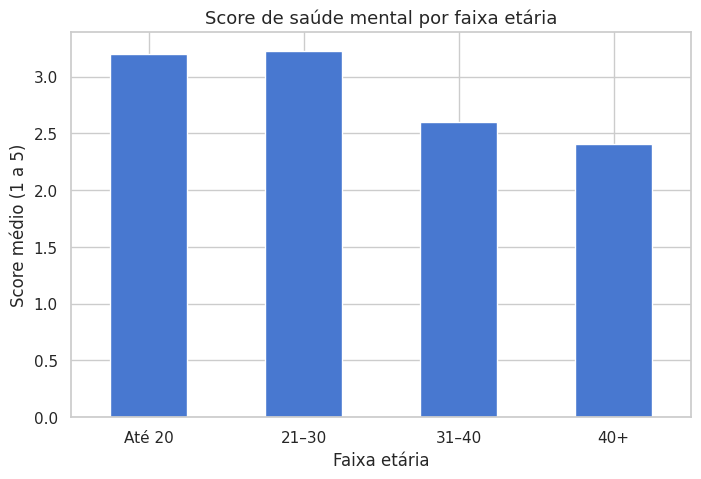

In [52]:
# Criar faixas etárias
df_proc['faixa_idade'] = pd.cut(
    df_proc['idade'],
    bins=[0, 20, 30, 40, 100],
    labels=['Até 20', '21–30', '31–40', '40+']
)

# Média do score por faixa
media_idade = df_proc.groupby('faixa_idade')['score_saude_mental'].mean().round(2)

print(media_idade)

# Gráfico
media_idade.plot(kind='bar', figsize=(8,5))
plt.title('Score de saúde mental por faixa etária')
plt.ylabel('Score médio (1 a 5)')
plt.xlabel('Faixa etária')
plt.xticks(rotation=0)
plt.show()

A análise da relação entre faixa etária e o score geral de saúde mental indica um padrão claro de variação entre os grupos.

Observa-se que os participantes mais jovens apresentam, em média, valores mais elevados no score, com destaque para a faixa de **21 a 30 anos**, seguida pela faixa de **até 20 anos**.

Por outro lado, as faixas etárias mais altas (**31–40 e 40+**) apresentam médias significativamente menores, indicando menor intensidade dos indicadores analisados.

Esse comportamento sugere uma associação entre menor idade e maiores níveis de impacto nos indicadores de saúde mental, embora o efeito não seja estritamente linear.

Dessa forma, os resultados fornecem evidência para a hipótese de que indivíduos mais jovens tendem a apresentar maiores níveis de impacto, com maior destaque para adultos jovens.


### Relação entre Tempo de Uso e Score Geral
Com os dados devidamente tratados e enriquecidos por meio da criação de índices compostos, abaixo vai permitir observar relações mais claras entre o tempo de uso de redes sociais e indicadores de saúde mental.


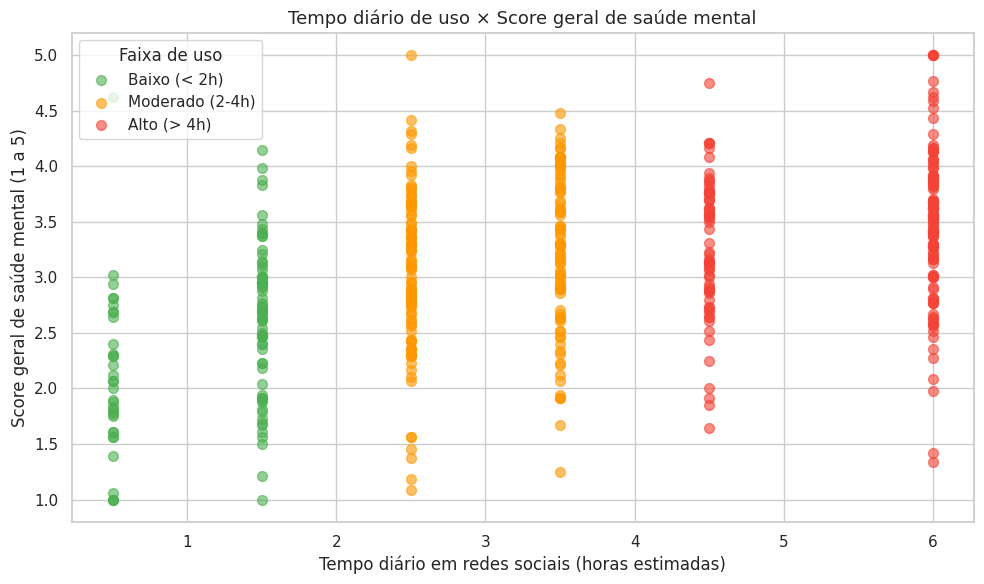

In [53]:
# Scatter plot: tempo de uso × score geral de saúde mental
plt.figure(figsize=(10, 6))

cores_faixa = {'Baixo (< 2h)': '#4CAF50', 'Moderado (2-4h)': '#FF9800', 'Alto (> 4h)': '#F44336'}

for faixa, cor in cores_faixa.items():
    subset = df_proc[df_proc['faixa_uso'] == faixa]
    plt.scatter(
        subset['tempo_diario_horas'],
        subset['score_saude_mental'],
        label=faixa, alpha=0.6, color=cor, s=50
    )

plt.title('Tempo diário de uso × Score geral de saúde mental')
plt.xlabel('Tempo diário em redes sociais (horas estimadas)')
plt.ylabel('Score geral de saúde mental (1 a 5)')
plt.legend(title='Faixa de uso')
plt.tight_layout()
plt.show()

###Comparação dos Índices por Faixa de Uso


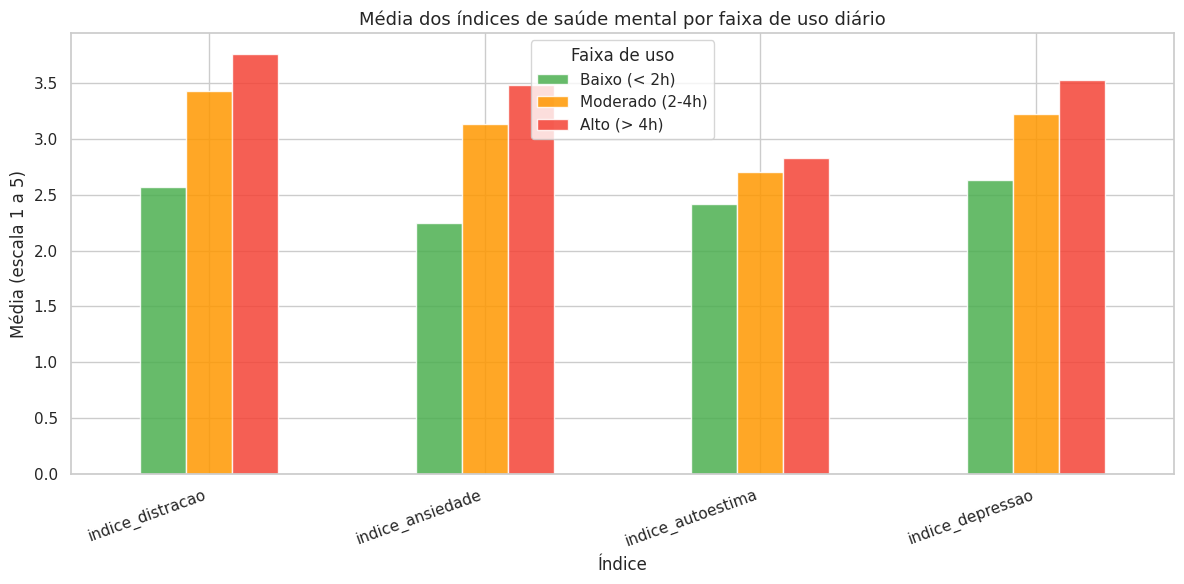

In [54]:
# Barras comparativas: índices médios por faixa de uso
indices = ['indice_distracao', 'indice_ansiedade', 'indice_autoestima', 'indice_depressao']

medias_por_faixa = df_proc.groupby('faixa_uso')[indices].mean().round(2)

medias_por_faixa.T.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#4CAF50', '#FF9800', '#F44336'],
    edgecolor='white',
    alpha=0.85
)

plt.title('Média dos índices de saúde mental por faixa de uso diário')
plt.xlabel('Índice')
plt.ylabel('Média (escala 1 a 5)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Faixa de uso')
plt.tight_layout()
plt.show()

## Análise dos Resultados Pós-Pré-processamento

A partir das visualizações obtidas, é possível observar padrões relevantes na relação entre o tempo de uso de redes sociais e os indicadores de saúde mental.

---

### Relação entre Tempo de Uso e Score Geral

O gráfico de dispersão indica uma **tendência positiva moderada** entre o tempo diário de uso e o score geral de saúde mental.

Observa-se que:

* Usuários com **baixo tempo de uso (< 2h)** concentram-se majoritariamente em valores mais baixos do score (entre 1.5 e 3.0)
* Usuários com **uso moderado (2–4h)** apresentam maior dispersão, com valores intermediários
* Usuários com **uso alto (> 4h)** apresentam maior concentração em valores mais elevados (acima de 3.0)

No entanto, a presença de dispersão significativa em todas as faixas indica que o comportamento não é uniforme, sugerindo que outros fatores também influenciam os resultados.

---

### Comparação dos Índices por Faixa de Uso

O gráfico de barras evidencia um padrão **consistente e crescente** entre as faixas de uso:

* Em todos os índices, observa-se aumento progressivo de:

  * Baixo → Moderado → Alto uso

---

### Destaques por Índice

* **Índice de Distração**: apresenta o maior crescimento entre as faixas, sendo o mais sensível ao aumento do tempo de uso
* **Índice de Ansiedade**: também apresenta aumento relevante, indicando associação consistente
* **Índice de Depressão**: mostra crescimento significativo, especialmente entre uso moderado e alto
* **Índice de Autoestima/Comparação Social**: apresenta aumento mais sutil, indicando efeito menos pronunciado

---

### Interpretação dos Resultados

Embora exista uma tendência clara de aumento dos indicadores com o tempo de uso, os gráficos também mostram:

* Alta variabilidade dentro de cada grupo
* Sobreposição entre faixas de uso
* Presença de indivíduos com baixos scores mesmo em alto uso

Isso sugere que a relação não é determinística, mas sim uma **associação probabilística**.

---

### Validação das Hipóteses

Com base nas evidências observadas:

* **H1 — Existe relação entre tempo de uso e saúde mental:** <br/>
  **Confirmada (associação moderada)**

* **H2 — Uso excessivo aumenta distração e ansiedade:** <br/>
  **Confirmada (especialmente forte para distração)**

* **H3: Usuários mais jovens tendem a apresentar maiores índices de impacto na saúde mental:** <br/>
**Parcialmente confirmada — há evidência de que indivíduos mais jovens apresentam maiores níveis de impacto, com destaque para a faixa de 21 a 30 anos, embora a relação não seja estritamente linear.**


* **H4 — Usuários intensivos apresentam piores indicadores gerais:** <br/>
  **Parcialmente confirmada**
  (há tendência clara, mas com alta variabilidade)

---

### Conclusão da Análise

Os resultados indicam que o aumento do tempo de uso de redes sociais está associado a elevação nos indicadores de saúde mental analisados, especialmente em relação à distração, ansiedade e depressão.

No entanto, a presença de variabilidade significativa sugere que o impacto do uso de redes sociais não é uniforme entre os indivíduos, sendo influenciado por outros fatores não capturados no dataset.

Essa análise reforça a importância de abordagens mais aprofundadas e multifatoriais para compreender o impacto das redes sociais no bem-estar psicológico.



## 8. Conclusões

### Principais achados

1. **Perfil da amostra:** A amostra é composta majoritariamente por indivíduos jovens, com forte presença de estudantes universitários, o que é consistente com a origem do dataset. Esse perfil indica um público altamente exposto ao uso de tecnologias digitais e redes sociais.

2. **Distribuição de uso:** Observou-se que a maior parte dos respondentes utiliza redes sociais por mais de 2 horas diárias, com destaque para as faixas de uso moderado (2–4h) e alto (>4h). A categoria de uso intensivo representa uma parcela significativa da amostra, indicando elevado nível de exposição digital.

3. **Correlações identificadas:** A análise de correlação revelou associações positivas entre variáveis relacionadas ao uso de redes sociais e indicadores de saúde mental. Destacam-se correlações moderadas entre distração, dificuldade de concentração e níveis de preocupação, além da associação entre ansiedade e sintomas depressivos.

4. **Índices compostos:** A criação de índices compostos permitiu sintetizar diferentes dimensões da saúde mental. Observou-se que os maiores valores médios estão associados aos índices de distração e depressão, enquanto o índice de comparação social apresentou maior variabilidade entre os respondentes.

5. **Validação das hipóteses:** Os resultados indicam uma associação consistente entre maior tempo de uso de redes sociais e aumento nos indicadores de saúde mental analisados.
* H1: Confirmada — existe relação entre tempo de uso e saúde mental
* H2: Confirmada — uso mais intenso está associado a maiores níveis de distração e ansiedade
* H3: Parcialmente confirmada — há evidência de que indivíduos mais jovens apresentam maiores níveis de impacto, com destaque para a faixa de 21 a 30 anos, embora a relação não seja estritamente linear.
* H4: Parcialmente confirmada — usuários intensivos apresentam, em média, piores indicadores, embora com variabilidade significativa entre indivíduos

De forma geral, os achados reforçam a hipótese de que o uso intensivo de redes sociais está associado a impactos no bem-estar psicológico, ainda que não de forma determinística.

### Limitações

- O dataset é proveniente de um survey universitário, o que limita a generalização dos resultados para a população geral.
- A variável de tempo diário é auto-declarada e pode estar sujeita a viés de memória.
- Correlação não implica causalidade: os achados indicam associação, não relação causal direta.

### Consideração Final

Os dados pré-processados (normalizados e com índices compostos) estão preparados para uma eventual etapa de modelagem preditiva, como regressão logística para prever necessidade de suporte psicológico, ou clustering para segmentação de perfis de usuários.
